# Libraries

In [1]:
import os
os.environ["MKL_THREADING_LAYER"] = "TBB"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

In [2]:
# for random generation
import numpy as np 
import random as rd


# basic functions
import pandas as pd
from scipy import stats, sparse
import matplotlib.pyplot as plt
import time
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cs
pd.options.display.max_rows = 100
import matplotlib
# custom-made functions
import analysis
from enrich import calculate_userKNN_characteristics, calculate_sparsity_cumulatively, calculate_user_similarities
import modelling
import modelling_old
from plot import produce_complete_analysis, compare_sparsity_evolution
from data_generation import from_sparsities_to_nr_users_per_item, generate_data, generate_data_more
from scipy.stats import kendalltau

# lenskit RS library
from lenskit import crossfold as xf
from lenskit.algorithms import Recommender, item_knn, user_knn
from lenskit import util, batch, topn
from lenskit.metrics.predict import rmse

# cornac RS library
import cornac
from cornac.eval_methods import BaseMethod
from cornac.models import ItemKNN, UserKNN
from cornac.metrics import RMSE

# Fairbook data and parameters

In [5]:
data="fairbook"
# user-item interactions
fairbook_ratings = pd.read_csv("data/"+data+"_events.csv")

In [6]:
user_col = "user" # the name of the column that includes the users
item_col = "item" # the name of the column that includes the items
predict_col="rating" # the name of the column that includes the interaction
popularity_function = {'pop_one': "pop_fraq", 
             'pop_two': "pop_item_fraq"} # which criterion will be used...depricated
pop_notion="pop_one" # depricated

# Scenarios

Crucial question: Do users with big profiles have many popular items?

1. There is no general relation between popularity and rating. 
2. Popular items are rated higher by the users.
3. Popular items are rated lower by  some users.
    - Users with big profiles.
    - Users with small profiles.
5. Popular items are rated lower by users with big profiles.
    - Users with big profiles.
    - Users with small profiles.
    
**Who consumes the quality items????**

In [7]:
ratings = generate_data_more(strategy = "popularity_good_for_bp_ur",
                            copying_dataset = fairbook_ratings,
                            user_perc = 0.2)

In [8]:
# calculate user and item distributions, confirm the settings
user_dist,num_users = analysis.user_distribution(ratings,"user","item", verbose=True)
item_dist,num_items = analysis.item_distribution(ratings,"user","item", verbose = True)
df_item_dist = pd.DataFrame(item_dist).rename(columns={"item":"count"}) # dataframe format

Mean items per user: 13.9
Min items per user: 5
Max items per user: 153


Mean users per item: 12.8
Min users per item: 5
Max users per item: 350




In [9]:
num_users, num_items

(6358, 6921)

In [17]:
# user_characteristics, item_characteristics = calculate_userKNN_characteristics(ratings = ratings, 
#                                                                             user_dist = user_dist, 
#                                                                             item_dist = item_dist,
#                                                                             user_col = user_col, 
#                                                                             item_col = item_col, 
#                                                                             predict_col = predict_col, 
#                                                                             df_item_dist = df_item_dist, 
#                                                                             divide_by = popularity_function[pop_notion])

In [18]:
# analysis.plot_data_distribution(item_dist, 
#                                 user_dist, 
#                                 item_characteristics.rating.values,
#                                 user_characteristics.rating.values,
#                                 item_col, 
#                                 user_col)

In [19]:
# analysis.plot_rating_distribution(ratings.rating.values,user_characteristics.rating,item_characteristics.rating, 
#                                  rating_range = [1,10])

In [20]:
# produce_complete_analysis(user_characteristics, item_characteristics, mc = False)

In [21]:
# produce_complete_analysis(user_characteristics, item_characteristics, mc = True)

In [10]:
evaluation_way = "cross_validation"
nnbrs = num_users
verbose = True
fallback = False
nr_recs = 10
sampling_strategy = "frac"
partition_way = "user"

# Functions

In [11]:
algorithm = user_knn.UserUser
algo_name = "UserKNN"

algorithm_cornac = UserKNN

## MC -1

0 Training done!
Prediction done!
0 Recommendation done!
1 Training done!
Prediction done!
1 Recommendation done!
2 Training done!
Prediction done!
2 Recommendation done!
3 Training done!
Prediction done!
3 Recommendation done!
4 Training done!
Prediction done!
4 Recommendation done!


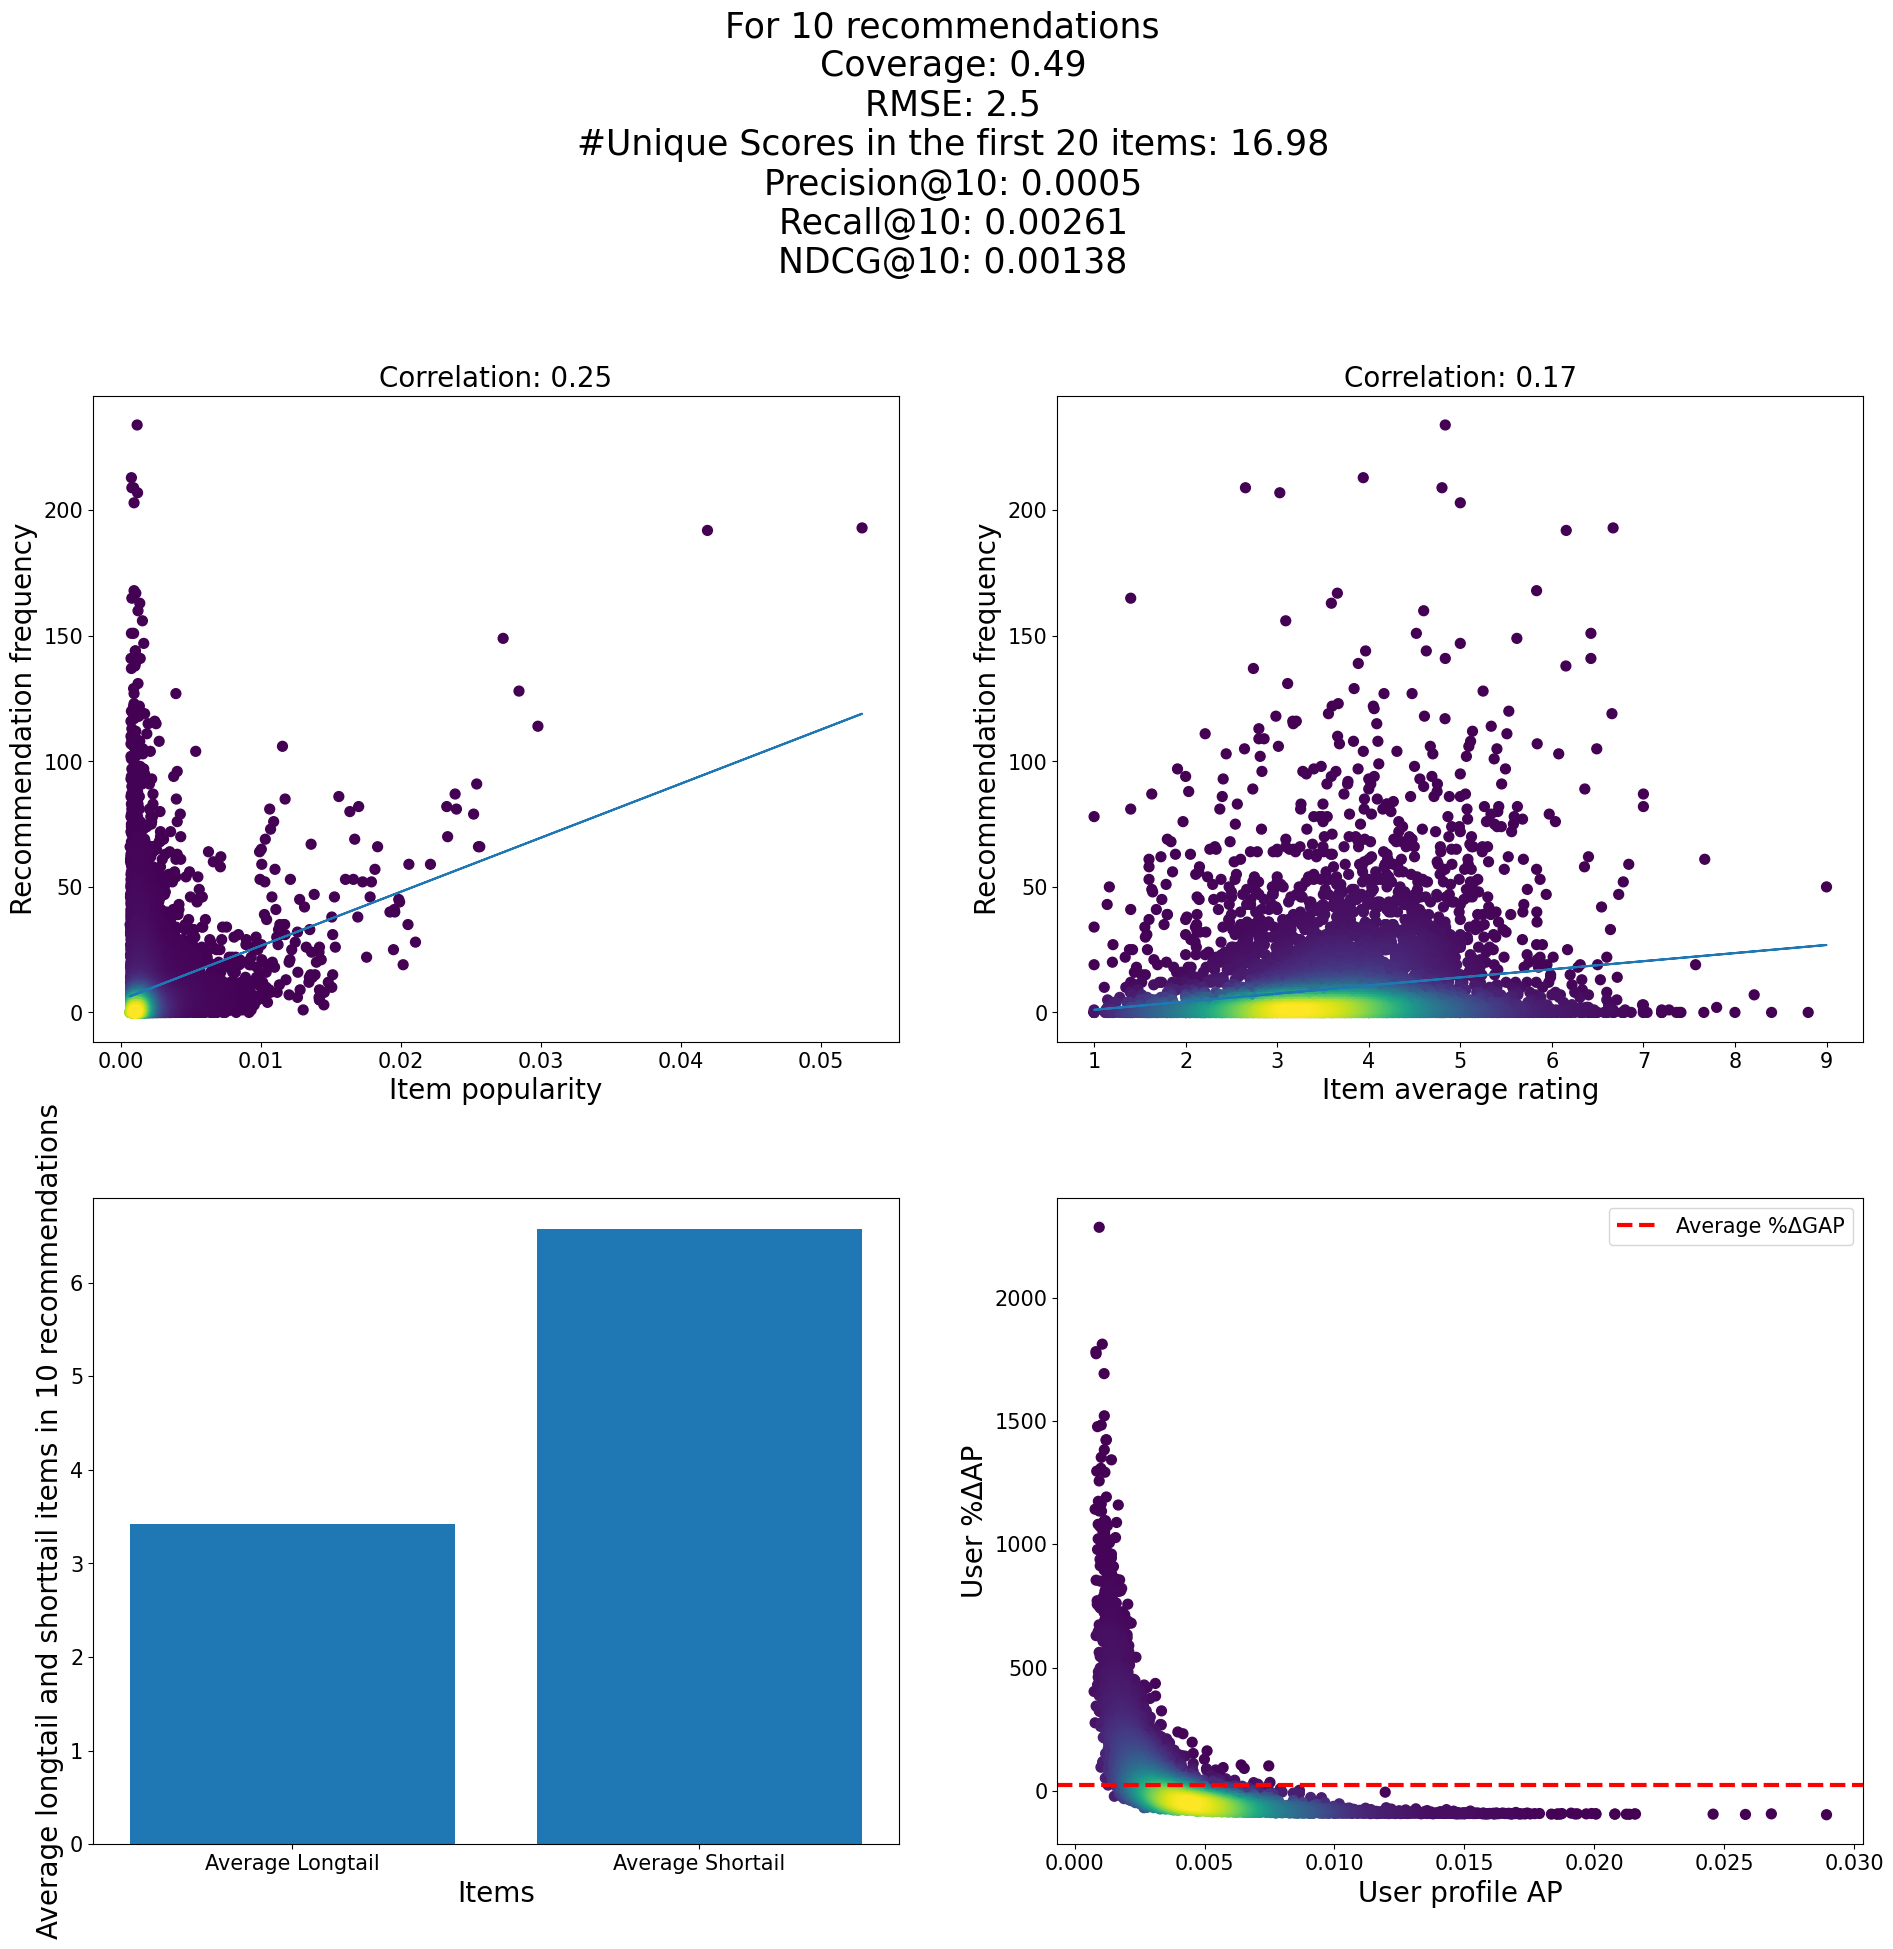

In [12]:
pop_biases = modelling.train_algorithm(algorithm = algorithm, 
                          algo_name = algo_name, 
                          centering = True, 
                          nnbrs = nnbrs, 
                          ratings = ratings,
                          
                          evaluation_way = evaluation_way,
                          verbose = verbose, 
                                       min_sim=-1,
                                       fallback=fallback,
                                       n=nr_recs,
                                       sampling_strategy = sampling_strategy,
                                       partition_way = partition_way
                          )

## Not MC

0 Training done!
Prediction done!
0 Recommendation done!
1 Training done!
Prediction done!
1 Recommendation done!
2 Training done!
Prediction done!
2 Recommendation done!
3 Training done!
Prediction done!
3 Recommendation done!
4 Training done!
Prediction done!
4 Recommendation done!


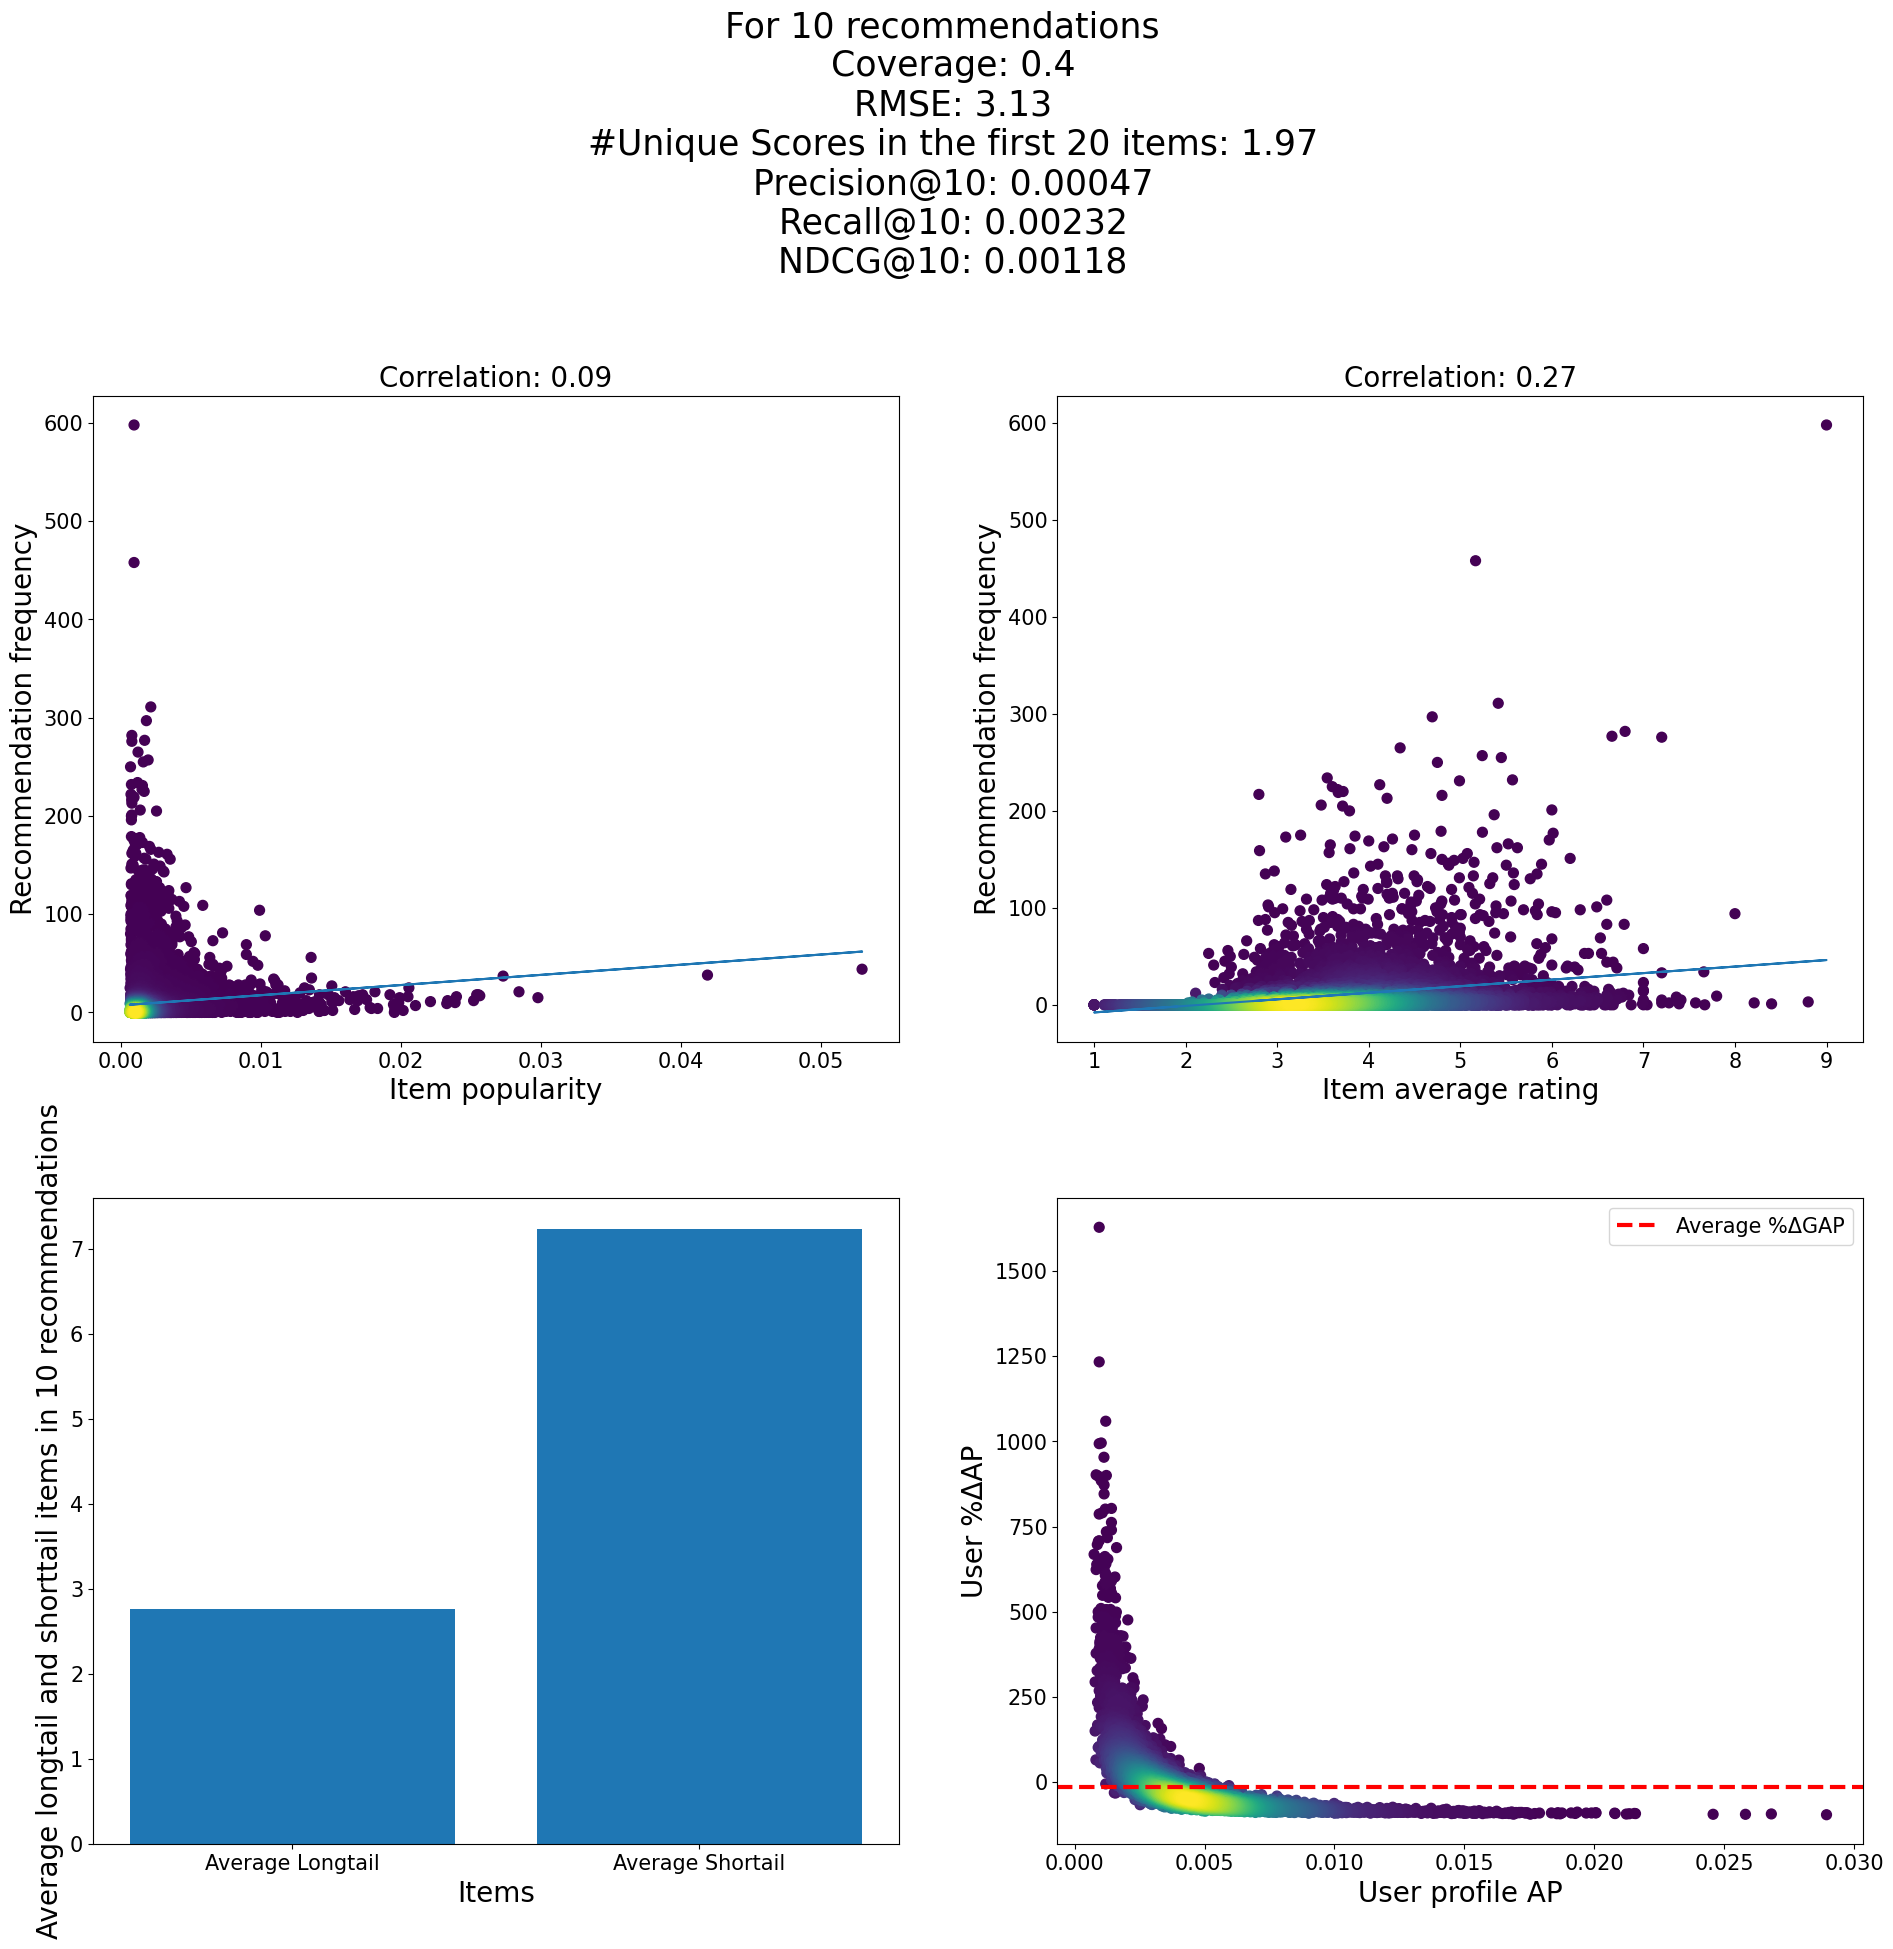

In [13]:
pop_biases = modelling.train_algorithm(algorithm = algorithm, 
                          algo_name = algo_name, 
                          centering = False, 
                          nnbrs = nnbrs, 
                          ratings = ratings,
                          
                          evaluation_way = evaluation_way,
                          verbose = verbose,
                                       fallback=fallback,
                                       n=nr_recs,
                                      sampling_strategy = sampling_strategy,
                                      partition_way = partition_way)

Print average recommendation popularity. 

## MC 0

0 Training done!
Prediction done!
0 Recommendation done!
1 Training done!
Prediction done!
1 Recommendation done!
2 Training done!
Prediction done!
2 Recommendation done!
3 Training done!
Prediction done!
3 Recommendation done!
4 Training done!
Prediction done!
4 Recommendation done!


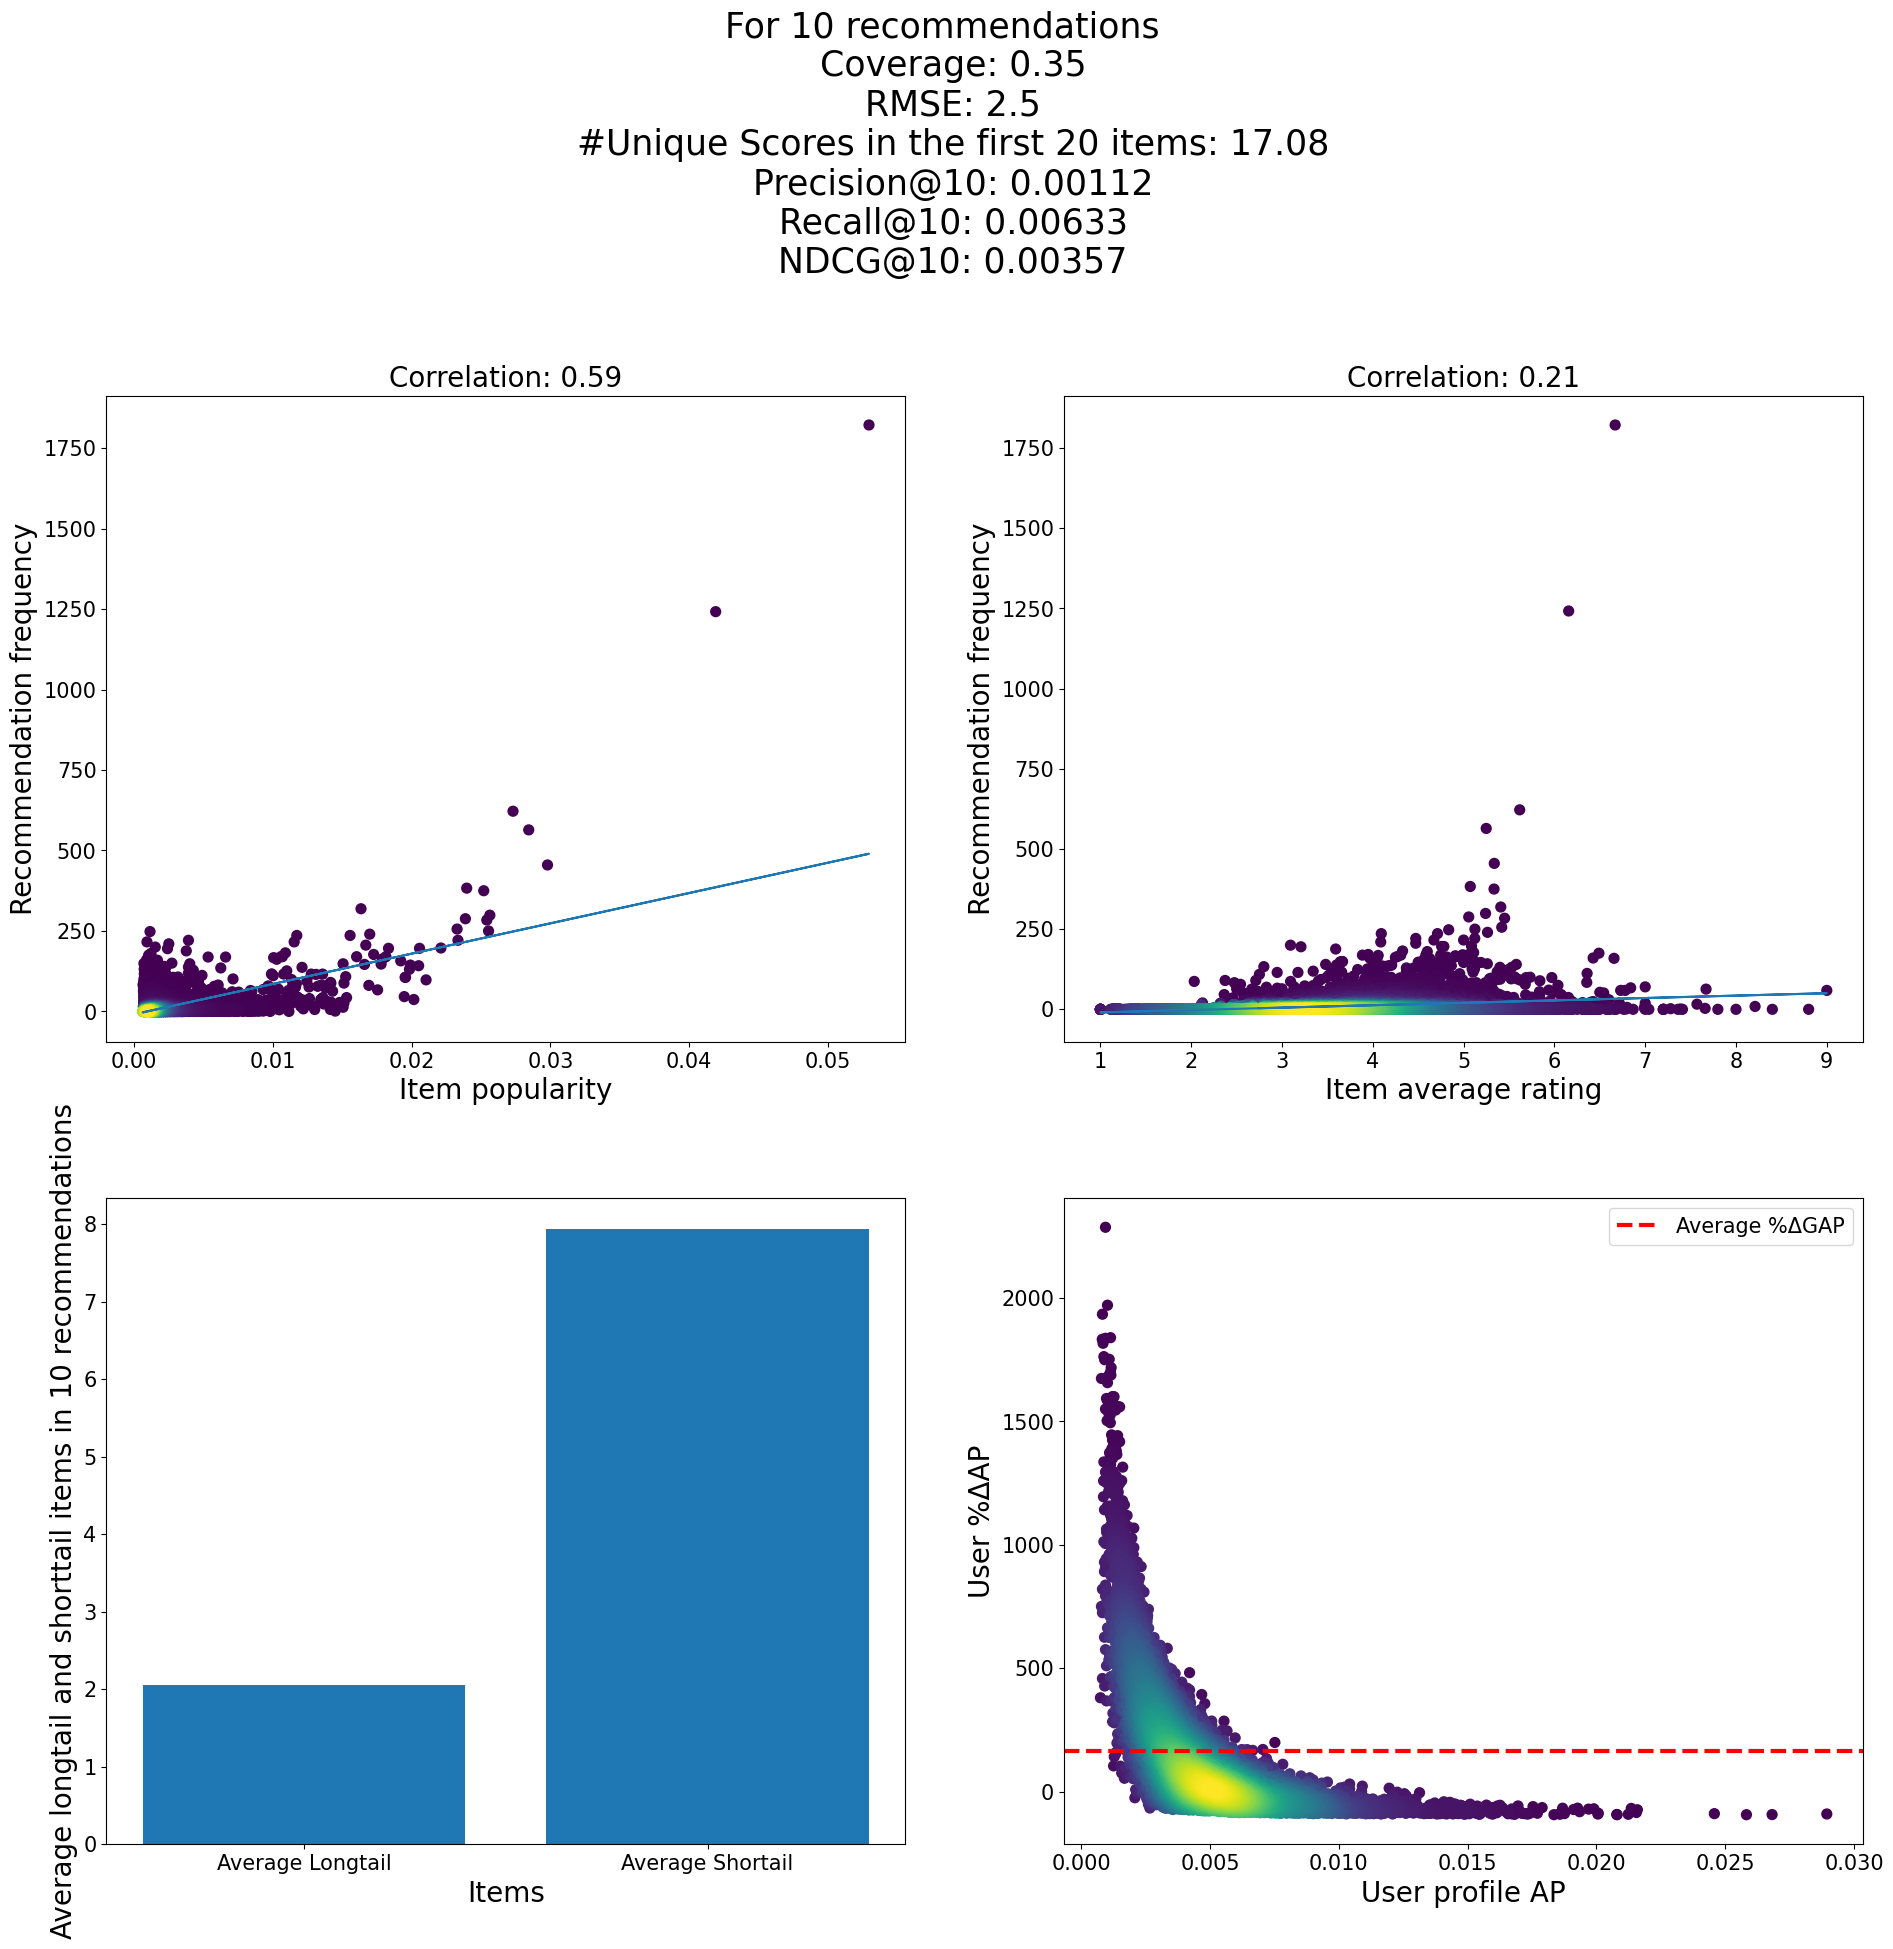

In [14]:
pop_biases = modelling.train_algorithm(algorithm = algorithm, 
                          algo_name = algo_name, 
                          centering = True, 
                          nnbrs = nnbrs, 
                          ratings = ratings,
                          
                          evaluation_way = evaluation_way,
                          verbose = verbose, 
                                       min_sim=0,
                                       fallback=fallback,
                                       n=nr_recs,
                                      sampling_strategy = sampling_strategy,
                                      partition_way = partition_way)
            

# Mean Centered but over common

What is the effect of over common? Well, that even if two users havent rated many items in common, their similarity will be high if they agree on the few ones they've rated. Therefore, users with small profiles can be influential. That's why pop bias reduces

The other thing that matters is min_sim.

  0%|          | 0/6358 [00:00<?, ?it/s]

UserKNN model is saved to cornacLogs/UserKNN/2023-04-24_20-07-47-134722.pkl

TEST:
...
        |   RMSE | Train (s) | Test (s)
------- + ------ + --------- + --------
UserKNN | 2.4604 |    1.1572 |   0.4420

Training done!
Recommendation done!


  0%|          | 0/6358 [00:00<?, ?it/s]

UserKNN model is saved to cornacLogs/UserKNN/2023-04-24_20-08-16-249613.pkl

TEST:
...
        |   RMSE | Train (s) | Test (s)
------- + ------ + --------- + --------
UserKNN | 2.4775 |    1.2084 |   0.4233

Training done!
Recommendation done!


  0%|          | 0/6358 [00:00<?, ?it/s]

UserKNN model is saved to cornacLogs/UserKNN/2023-04-24_20-08-43-656962.pkl

TEST:
...
        |   RMSE | Train (s) | Test (s)
------- + ------ + --------- + --------
UserKNN | 2.4060 |    1.2089 |   0.4487

Training done!
Recommendation done!


  0%|          | 0/6358 [00:00<?, ?it/s]

UserKNN model is saved to cornacLogs/UserKNN/2023-04-24_20-09-14-362570.pkl

TEST:
...
        |   RMSE | Train (s) | Test (s)
------- + ------ + --------- + --------
UserKNN | 2.4306 |    1.1749 |   0.4472

Training done!
Recommendation done!


  0%|          | 0/6358 [00:00<?, ?it/s]

UserKNN model is saved to cornacLogs/UserKNN/2023-04-24_20-09-41-770951.pkl

TEST:
...
        |   RMSE | Train (s) | Test (s)
------- + ------ + --------- + --------
UserKNN | 2.5176 |    1.1981 |   0.4254

Training done!
Recommendation done!


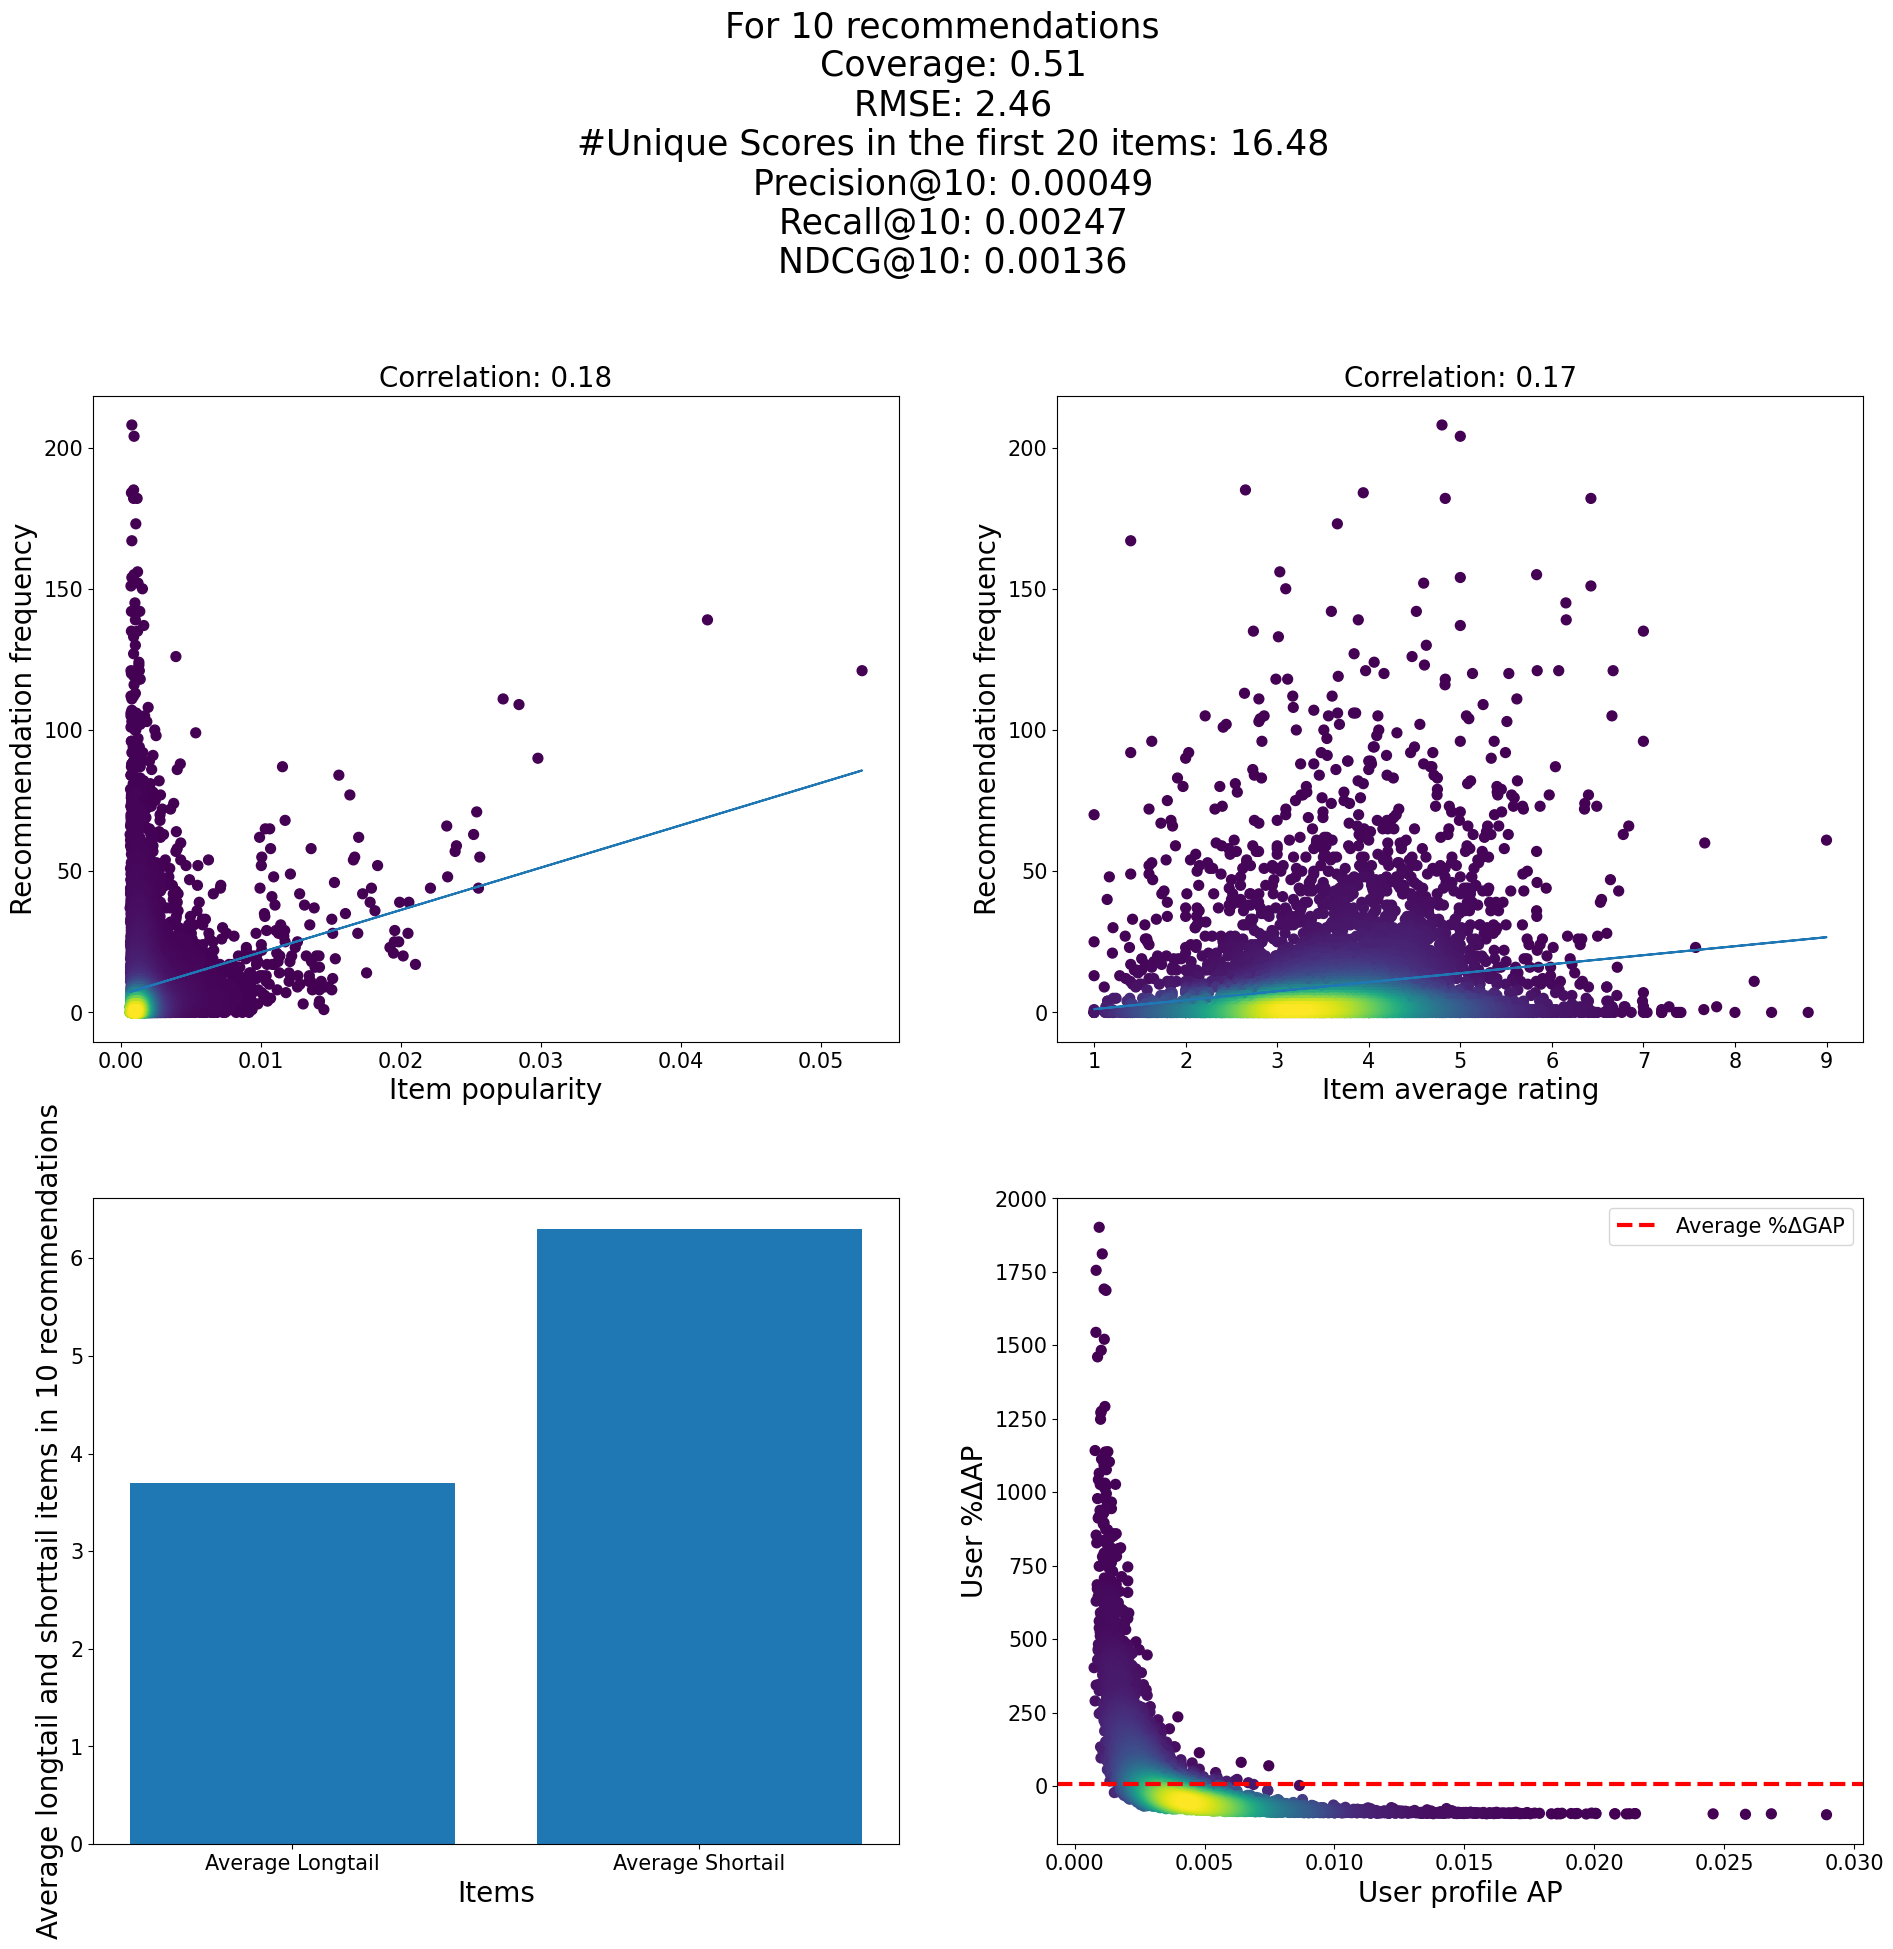

In [15]:
pop_biases = modelling.train_algorithm_cornac(algorithm = algorithm_cornac, 
                          algo_name = algo_name, 
                          centering = True, 
                          nnbrs = nnbrs, 
                          ratings = ratings,
                          
                          evaluation_way = evaluation_way,
                                              partition_way = partition_way,
                          verbose = verbose,
                                       n=nr_recs,
                                              sampling_strategy = sampling_strategy
                          
                          )